# 🌐 Week 1 Extra — From Real-World APIs to Data Streams

**Data Stream Mining — NOVA IMS**  
**Optional / Reference Notebook**

---

## Why this notebook exists

Real streaming projects rarely begin with a perfectly prepared CSV file.

Data often arrives from:

- weather stations,
- energy systems,
- environmental sensors,
- IoT devices,
- public data platforms,
- web services and APIs.

This notebook shows how to go from:

**REAL-WORLD API → JSON → TABULAR DATA → TIMESTAMPED OBSERVATIONS → REPLAY STREAM**

It is designed to be both:

1. an **extra Week 1 laboratory resource**, and
2. a **reference for the Practical Assignments**.

> **Important:** This notebook is not an assessment.  
> Some cells require an active internet connection.

### Main data sources used here

- 🇵🇹 **IPMA** — Portuguese meteorological station observations
- 🇵🇹 **REN Data Hub** — Portuguese electricity and gas data
- 🌍 **Open-Meteo** — easy-to-use weather API
- 📡 **ThingSpeak** — public IoT channels

The course may introduce additional data sources later.

## Learning goals

By the end of this notebook, you should be able to:

- explain what an API is;
- make a simple HTTP `GET` request in Python;
- inspect a JSON response;
- convert nested API data into a `pandas.DataFrame`;
- work correctly with timestamps;
- identify missing/sentinel values;
- save the **raw response** before preprocessing it;
- create a reproducible **replay stream** from historical observations;
- understand the difference between **pull/polling** and **push/event streaming**;
- document data provenance for a practical report.

# 0. Before We Start — What Is a "Real Stream"?

The word **stream** can refer to several ways of receiving data.

### A. Pull / REST API

Your program asks the server:

> "Do you have new data?"

```text
Python → HTTP GET → API → JSON response
```

If we repeat the request periodically, we are **polling** the API.

---

### B. Push / Event Stream

The server sends new observations when they become available.

Examples include:

- MQTT
- WebSockets
- Kafka topics
- event brokers

```text
Sensor → Broker → Subscriber → New observation
```

---

### C. Historical Replay

We obtain timestamped historical observations, order them by time, and present them to the algorithm **one observation at a time**.

```text
Historical records
        ↓
sort by timestamp
        ↓
observation 1
observation 2
observation 3
...
```

For coursework, **replay is extremely useful** because it preserves the streaming logic while making experiments reproducible.

## 🔑 Key principle for the Practical Assignments

A live API is excellent for **collecting data**.

A saved snapshot is better for **reproducible evaluation**.

A good workflow is therefore:

**API → SAVE RAW DATA → CLEAN/PREPARE → REPLAY AS STREAM → MODEL → EVALUATE**

This prevents your report from becoming impossible to reproduce if:

- the API is temporarily unavailable;
- the provider changes an endpoint;
- new data appears after your analysis;
- the values are revised;
- your internet connection fails.

# 1. Environment Setup

We will use a small set of familiar libraries.

### Main packages

- `requests` — HTTP requests
- `pandas` — tabular data
- `numpy` — numerical operations
- `matplotlib` — visualization
- `json` — saving raw JSON
- `pathlib` — file paths

Run the installation cell only if necessary.

In [1]:
# Uncomment if needed
%pip install -q requests pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import json
import os
import time
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

pd.set_option("display.max_columns", 100)

RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data folder:", RAW_DIR.resolve())
print("Processed data folder:", PROCESSED_DIR.resolve())

Raw data folder: C:\Users\psouza\Desktop\Data Stream Mining\data\raw
Processed data folder: C:\Users\psouza\Desktop\Data Stream Mining\data\processed


## 🔵 Reusable helper — safe JSON request

APIs can fail.

A robust notebook should not assume that every request succeeds.

Possible problems include:

- no internet connection;
- server unavailable;
- timeout;
- wrong endpoint;
- invalid parameters;
- rate limits;
- authentication failure;
- non-JSON response.

We will use the following helper throughout the notebook.

In [2]:
def fetch_json(url, params=None, headers=None, timeout=30):
    """Fetch JSON from an HTTP endpoint and return (data, response).

    Raises a requests exception if the request fails.
    """
    default_headers = {
        "User-Agent": "NOVA-IMS-Data-Stream-Mining-Educational-Notebook/1.0"
    }

    if headers:
        default_headers.update(headers)

    response = requests.get(
        url,
        params=params,
        headers=default_headers,
        timeout=timeout
    )
    response.raise_for_status()

    return response.json(), response

# 2. API Basics — HTTP, JSON, and Python

A common REST API workflow is:

```text
URL + PARAMETERS
       ↓
   HTTP GET
       ↓
     SERVER
       ↓
  JSON RESPONSE
       ↓
 Python objects
```

A JSON response often becomes:

- a Python `dict`,
- a Python `list`,
- or a nested combination of both.

Before building a DataFrame, **inspect the structure**.

In [3]:
# A local JSON example — no internet required
example_json = {
    "station": "Example Station",
    "timestamp": "2026-09-05T10:00:00",
    "temperature": 22.4,
    "humidity": 61
}

print(type(example_json))
print(example_json)
print("Temperature:", example_json["temperature"])

<class 'dict'>
{'station': 'Example Station', 'timestamp': '2026-09-05T10:00:00', 'temperature': 22.4, 'humidity': 61}
Temperature: 22.4


## A useful habit: inspect before transforming

When using a new API, ask:

1. Is the top-level object a `dict` or a `list`?
2. Which keys exist?
3. Where are the observations?
4. Where is the timestamp?
5. Are numeric values actually numbers or strings?
6. How are missing values represented?

In [4]:
def inspect_json(obj, name="root", max_items=5):
    """Small helper for inspecting an unfamiliar JSON object."""
    print(f"{name}: {type(obj).__name__}")

    if isinstance(obj, dict):
        keys = list(obj.keys())
        print("Keys:", keys[:max_items])
        if len(keys) > max_items:
            print(f"... {len(keys) - max_items} more keys")

    elif isinstance(obj, list):
        print("Length:", len(obj))
        if obj:
            print("First item type:", type(obj[0]).__name__)
            print("First item:", obj[0])

inspect_json(example_json)

root: dict
Keys: ['station', 'timestamp', 'temperature', 'humidity']


# 3. 🇵🇹 IPMA — Portuguese Meteorological Observations

The IPMA open-data service publishes:

- a station catalogue;
- recent meteorological observations.

Official endpoints used in this notebook:

```text
https://api.ipma.pt/open-data/observation/meteorology/stations/stations.json
https://api.ipma.pt/open-data/observation/meteorology/stations/observations.json
```

The observation endpoint is naturally interesting for Data Stream Mining because measurements are organized by **timestamp** and **station**.

Typical variables include:

- temperature,
- humidity,
- pressure,
- precipitation,
- wind,
- radiation.

In [5]:
IPMA_STATIONS_URL = (
    "https://api.ipma.pt/open-data/observation/"
    "meteorology/stations/stations.json"
)

IPMA_OBSERVATIONS_URL = (
    "https://api.ipma.pt/open-data/observation/"
    "meteorology/stations/observations.json"
)

print(IPMA_STATIONS_URL)
print(IPMA_OBSERVATIONS_URL)

https://api.ipma.pt/open-data/observation/meteorology/stations/stations.json
https://api.ipma.pt/open-data/observation/meteorology/stations/observations.json


## 3.1 Download the station catalogue

The catalogue contains the station identifier, name, and geographic coordinates.

In [6]:
try:
    ipma_stations_json, response = fetch_json(IPMA_STATIONS_URL)
    print("HTTP status:", response.status_code)
    print("Number of station records:", len(ipma_stations_json))
    IPMA_STATIONS_AVAILABLE = True
except requests.RequestException as exc:
    print("Could not reach the IPMA station endpoint.")
    print("Reason:", exc)
    IPMA_STATIONS_AVAILABLE = False
    ipma_stations_json = []

HTTP status: 200
Number of station records: 222


In [7]:
def ipma_stations_to_dataframe(stations_json):
    records = []

    for feature in stations_json:
        properties = feature.get("properties", {})
        geometry = feature.get("geometry", {})
        coordinates = geometry.get("coordinates") or [None, None]

        longitude = coordinates[0] if len(coordinates) > 0 else None
        latitude = coordinates[1] if len(coordinates) > 1 else None

        records.append({
            "station_id": str(properties.get("idEstacao")),
            "station_name": properties.get("localEstacao"),
            "longitude": longitude,
            "latitude": latitude,
        })

    return pd.DataFrame(records)


stations_df = ipma_stations_to_dataframe(ipma_stations_json)

if not stations_df.empty:
    display(stations_df.head(10))
else:
    print("No station data loaded.")

,station_id,station_name,longitude,latitude
0,1210881,"Olhão, EPPO",-7.821000,37.033000
1,1210883,Tavira,-7.620504,37.121670
2,6210817,Ponte de Sôr / Aeródromo,-8.054170,39.215360
3,11217430,Graciosa / Serra das Fontes (DROTRH),-28.003800,39.067200
4,6212121,Terras de Bouro/Barral (CIM),-8.318086,41.702253
5,6212122,Amares Caldelas (CIM),-8.379778,41.667964
6,1210907,Faja / Ilha das Flores,-31.264700,39.453280
7,6212124,Braga (CIM),-8.425147,41.535683
8,6212125,Barcelos (CIM),-8.627053,41.529375
9,6212126,Esposende (CIM),-8.779844,41.526456


### Find a station by name

Try changing `"Lisboa"` to:

- `Porto`
- `Braga`
- `Faro`
- `Coimbra`
- `Viseu`
- another location of interest.

In [8]:
STATION_SEARCH = "Lisboa"

if not stations_df.empty:
    station_matches = stations_df[
        stations_df["station_name"]
        .fillna("")
        .str.contains(STATION_SEARCH, case=False, regex=False)
    ]

    display(station_matches)
else:
    print("Load the station catalogue first.")

,station_id,station_name,longitude,latitude
65,1210580,"Lisboa, Relógio",-9.125400,38.761800
66,7240919,"Lisboa, Amoreiras (LFCL)",-9.164900,38.723900
97,6215302,"Lisboa, Carnide (CML)",-9.185500,38.775100
156,1200535,Lisboa (Geofísico),-9.149722,38.719078
221,1210762,"Lisboa, Tapada da Ajuda",-9.182825,38.709561


## 3.2 Download recent observations

The IPMA observation JSON has a nested structure similar to:

```text
timestamp
   ├── station A → variables
   ├── station B → variables
   └── station C → variables
```

This is an excellent example of why API data often needs **normalization** before analysis.

In [9]:
try:
    ipma_obs_json, response = fetch_json(IPMA_OBSERVATIONS_URL)
    print("HTTP status:", response.status_code)
    print("Number of timestamps:", len(ipma_obs_json))
    print("First timestamps:", list(ipma_obs_json.keys())[:3])
    IPMA_OBS_AVAILABLE = True
except requests.RequestException as exc:
    print("Could not reach the IPMA observation endpoint.")
    print("Reason:", exc)
    IPMA_OBS_AVAILABLE = False
    ipma_obs_json = {}

HTTP status: 200
Number of timestamps: 24
First timestamps: ['2026-09-09T12:00', '2026-09-08T15:00', '2026-09-09T14:00']


In [10]:
def ipma_observations_to_dataframe(observations_json):
    records = []

    for timestamp, station_map in observations_json.items():

        if not isinstance(station_map, dict):
            continue

        for station_id, values in station_map.items():

            # Some stations may have no observation at a timestamp.
            if values is None or not isinstance(values, dict):
                continue

            record = {
                "timestamp": pd.to_datetime(timestamp),
                "station_id": str(station_id)
            }
            record.update(values)
            records.append(record)

    df = pd.DataFrame(records)

    if df.empty:
        return df

    # In the current IPMA feed, -99 is frequently used as a
    # sentinel for unavailable measurements.
    # Always check provider documentation/metadata in real projects.
    numeric_columns = df.select_dtypes(include="number").columns
    df[numeric_columns] = df[numeric_columns].replace(-99, np.nan)

    return df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)


ipma_obs_df = ipma_observations_to_dataframe(ipma_obs_json)

if not ipma_obs_df.empty:
    print("Rows:", len(ipma_obs_df))
    print("Columns:", ipma_obs_df.columns.tolist())
    display(ipma_obs_df.head())
else:
    print("No observations loaded.")

Rows: 4706
Columns: ['timestamp', 'station_id', 'intensidadeVentoKM', 'temperatura', 'radiacao', 'idDireccVento', 'precAcumulada', 'intensidadeVento', 'humidade', 'pressao']


,timestamp,station_id,intensidadeVentoKM,temperatura,radiacao,idDireccVento,precAcumulada,intensidadeVento,humidade,pressao
0,2026-09-08 15:00:00,11217160,NaN,25.3,NaN,0,NaN,NaN,93.0,NaN
1,2026-09-08 16:00:00,11217160,8.3,26.4,1093.0,3,0.0,2.3,88.0,NaN
2,2026-09-08 17:00:00,11217160,5.8,26.7,1306.2,3,0.1,1.6,86.0,NaN
3,2026-09-08 18:00:00,11217160,7.6,26.5,1024.4,3,0.1,2.1,85.0,NaN
4,2026-09-08 19:00:00,11217160,4.0,25.7,463.9,4,0.0,1.1,90.0,NaN


## 3.3 Add station names and coordinates

The observation feed identifies stations by ID.

We join it with the station catalogue to obtain human-readable station names and coordinates.

In [11]:
if not ipma_obs_df.empty and not stations_df.empty:
    ipma_df = ipma_obs_df.merge(
        stations_df,
        on="station_id",
        how="left"
    )

    display(ipma_df.head())
else:
    ipma_df = pd.DataFrame()
    print("Both station metadata and observations are required.")

,timestamp,station_id,intensidadeVentoKM,temperatura,radiacao,idDireccVento,precAcumulada,intensidadeVento,humidade,pressao,station_name,longitude,latitude
0,2026-09-08 15:00:00,11217160,NaN,25.3,NaN,0,NaN,NaN,93.0,NaN,Santa Maria / Praia Formosa (DROTRH),-25.0917,36.9542
1,2026-09-08 16:00:00,11217160,8.3,26.4,1093.0,3,0.0,2.3,88.0,NaN,Santa Maria / Praia Formosa (DROTRH),-25.0917,36.9542
2,2026-09-08 17:00:00,11217160,5.8,26.7,1306.2,3,0.1,1.6,86.0,NaN,Santa Maria / Praia Formosa (DROTRH),-25.0917,36.9542
3,2026-09-08 18:00:00,11217160,7.6,26.5,1024.4,3,0.1,2.1,85.0,NaN,Santa Maria / Praia Formosa (DROTRH),-25.0917,36.9542
4,2026-09-08 19:00:00,11217160,4.0,25.7,463.9,4,0.0,1.1,90.0,NaN,Santa Maria / Praia Formosa (DROTRH),-25.0917,36.9542


## 3.4 Choose a station and visualize its recent measurements

The cell below automatically selects the first station matching `STATION_SEARCH`.

You can also set a station ID manually.

In [12]:
selected_station_id = None

if not stations_df.empty:
    matches = stations_df[
        stations_df["station_name"]
        .fillna("")
        .str.contains(STATION_SEARCH, case=False, regex=False)
    ]

    if not matches.empty:
        selected_station_id = matches.iloc[0]["station_id"]
    else:
        selected_station_id = stations_df.iloc[0]["station_id"]

print("Selected station ID:", selected_station_id)

if selected_station_id and not ipma_df.empty:
    selected_ipma = (
        ipma_df[ipma_df["station_id"] == selected_station_id]
        .sort_values("timestamp")
        .copy()
    )

    display(selected_ipma)
else:
    selected_ipma = pd.DataFrame()

Selected station ID: 1210580


,timestamp,station_id,intensidadeVentoKM,temperatura,radiacao,idDireccVento,precAcumulada,intensidadeVento,humidade,pressao,station_name,longitude,latitude
1209,2026-09-08 15:00:00,1210580,22.0,27.1,NaN,8,0.0,6.1,45.0,1020.2,"Lisboa, Relógio",-9.1254,38.7618
1210,2026-09-08 16:00:00,1210580,20.5,27.0,NaN,8,0.0,5.7,47.0,1020.0,"Lisboa, Relógio",-9.1254,38.7618
1211,2026-09-08 17:00:00,1210580,20.5,25.7,NaN,8,0.0,5.7,51.0,1019.6,"Lisboa, Relógio",-9.1254,38.7618
1212,2026-09-08 18:00:00,1210580,20.9,24.2,NaN,8,0.0,5.8,55.0,1019.4,"Lisboa, Relógio",-9.1254,38.7618
1213,2026-09-08 19:00:00,1210580,25.9,22.1,NaN,8,0.0,7.2,70.0,1019.4,"Lisboa, Relógio",-9.1254,38.7618
1214,2026-09-08 20:00:00,1210580,15.5,21.2,NaN,8,0.0,4.3,76.0,1019.7,"Lisboa, Relógio",-9.1254,38.7618
1215,2026-09-08 21:00:00,1210580,18.0,21.1,NaN,8,0.0,5.0,77.0,1020.2,"Lisboa, Relógio",-9.1254,38.7618
1216,2026-09-08 22:00:00,1210580,9.7,21.2,NaN,8,0.0,2.7,79.0,1020.4,"Lisboa, Relógio",-9.1254,38.7618
1217,2026-09-08 23:00:00,1210580,18.4,21.4,NaN,8,0.0,5.1,82.0,1020.1,"Lisboa, Relógio",-9.1254,38.7618
1218,2026-09-09 00:00:00,1210580,12.2,21.5,NaN,8,0.0,3.4,84.0,1019.9,"Lisboa, Relógio",-9.1254,38.7618


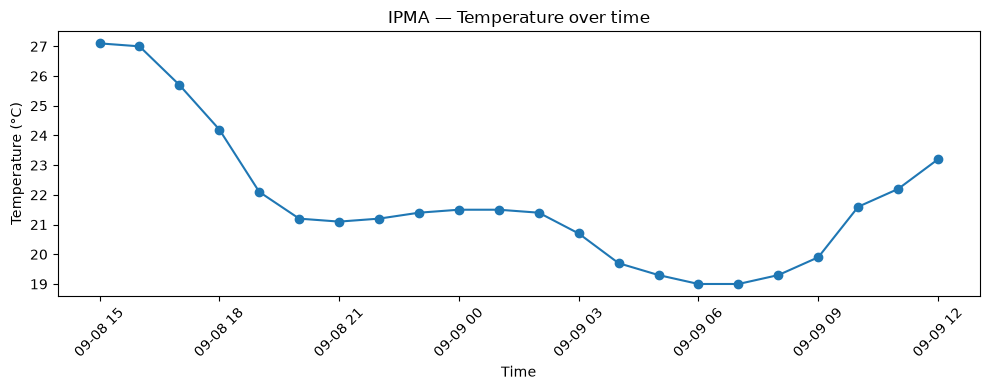

In [13]:
# Temperature over time
if not selected_ipma.empty and "temperatura" in selected_ipma.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(
        selected_ipma["timestamp"],
        selected_ipma["temperatura"],
        marker="o"
    )
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.title("IPMA — Temperature over time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Temperature data is not available for the selected station.")

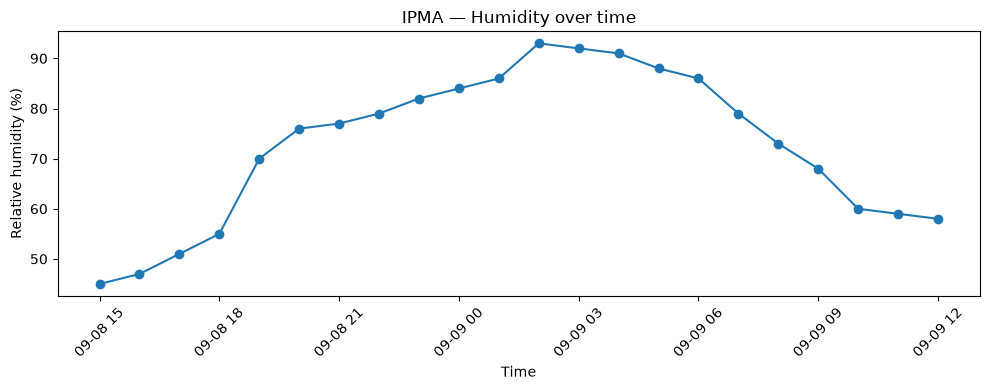

In [14]:
# Humidity over time
if not selected_ipma.empty and "humidade" in selected_ipma.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(
        selected_ipma["timestamp"],
        selected_ipma["humidade"],
        marker="o"
    )
    plt.xlabel("Time")
    plt.ylabel("Relative humidity (%)")
    plt.title("IPMA — Humidity over time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Humidity data is not available for the selected station.")

## 3.5 Save the raw and processed data

This is one of the most important habits in the notebook.

### Raw layer

Save exactly what the provider returned.

### Processed layer

Save the table used in your analysis.

Do **not** overwrite the raw data with a cleaned version.

In [15]:
def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    return path


if ipma_obs_json:
    raw_ipma_path = save_json(
        ipma_obs_json,
        RAW_DIR / "ipma_observations_snapshot.json"
    )
    print("Saved raw data:", raw_ipma_path)

if not ipma_df.empty:
    processed_ipma_path = (
        PROCESSED_DIR / "ipma_observations_processed.csv"
    )
    ipma_df.to_csv(processed_ipma_path, index=False)
    print("Saved processed data:", processed_ipma_path)

Saved raw data: data\raw\ipma_observations_snapshot.json
Saved processed data: data\processed\ipma_observations_processed.csv


# 4. From API Data to a Replay Stream

We now have timestamped data in a DataFrame.

Instead of giving the whole table to an algorithm at once, we can create a generator that yields observations sequentially.

This is the bridge from:

**API DATA → DATA STREAM MINING**

In [16]:
def dataframe_replay_stream(
    df,
    timestamp_col,
    feature_cols,
    target_col=None
):
    """Yield timestamped observations one at a time."""

    ordered = df.sort_values(timestamp_col)

    for _, row in ordered.iterrows():
        timestamp = row[timestamp_col]

        x = {
            col: row[col]
            for col in feature_cols
            if col in row.index and pd.notna(row[col])
        }

        if target_col is None:
            yield timestamp, x
        else:
            y = row[target_col]
            yield timestamp, x, y

In [17]:
# Example with the selected IPMA station
ipma_features = [
    "temperatura",
    "humidade",
    "pressao",
    "precAcumulada",
    "intensidadeVento"
]

if not selected_ipma.empty:
    stream = dataframe_replay_stream(
        selected_ipma,
        timestamp_col="timestamp",
        feature_cols=ipma_features
    )

    for i, observation in enumerate(stream):
        print(observation)

        if i >= 4:
            break
else:
    print("Load IPMA data first.")

(Timestamp('2026-09-08 15:00:00'), {'temperatura': 27.1, 'humidade': 45.0, 'pressao': 1020.2, 'precAcumulada': 0.0, 'intensidadeVento': 6.1})
(Timestamp('2026-09-08 16:00:00'), {'temperatura': 27.0, 'humidade': 47.0, 'pressao': 1020.0, 'precAcumulada': 0.0, 'intensidadeVento': 5.7})
(Timestamp('2026-09-08 17:00:00'), {'temperatura': 25.7, 'humidade': 51.0, 'pressao': 1019.6, 'precAcumulada': 0.0, 'intensidadeVento': 5.7})
(Timestamp('2026-09-08 18:00:00'), {'temperatura': 24.2, 'humidade': 55.0, 'pressao': 1019.4, 'precAcumulada': 0.0, 'intensidadeVento': 5.8})
(Timestamp('2026-09-08 19:00:00'), {'temperatura': 22.1, 'humidade': 70.0, 'pressao': 1019.4, 'precAcumulada': 0.0, 'intensidadeVento': 7.2})


## Streaming mindset

The algorithm does not need to receive:

```python
model.fit(complete_dataframe)
```

Instead, it may see:

```python
for timestamp, x in stream:
    process(x)
```

Later in the course, `process(x)` may become:

- update a statistic;
- make a prediction;
- update a classifier;
- update a metric;
- detect drift;
- detect an anomaly.

# 5. Incremental Statistics on Real API Data

Let's reuse the incremental-mean idea from the Week 1 refresher notebook.

The difference is that the values now come from a **real monitoring source**.

In [18]:
if not selected_ipma.empty and "temperatura" in selected_ipma.columns:
    temperature_stream = (
        selected_ipma[["timestamp", "temperatura"]]
        .dropna()
        .sort_values("timestamp")
    )

    running_means = []
    mean = 0.0

    for n, row in enumerate(
        temperature_stream.itertuples(index=False),
        start=1
    ):
        mean += (row.temperatura - mean) / n
        running_means.append(mean)

    temperature_stream = temperature_stream.copy()
    temperature_stream["running_mean"] = running_means

    display(temperature_stream)
else:
    temperature_stream = pd.DataFrame()
    print("Temperature data is not available.")

,timestamp,temperatura,running_mean
1209,2026-09-08 15:00:00,27.1,27.100000
1210,2026-09-08 16:00:00,27.0,27.050000
1211,2026-09-08 17:00:00,25.7,26.600000
1212,2026-09-08 18:00:00,24.2,26.000000
1213,2026-09-08 19:00:00,22.1,25.220000
1214,2026-09-08 20:00:00,21.2,24.550000
1215,2026-09-08 21:00:00,21.1,24.057143
1216,2026-09-08 22:00:00,21.2,23.700000
1217,2026-09-08 23:00:00,21.4,23.444444
1218,2026-09-09 00:00:00,21.5,23.250000


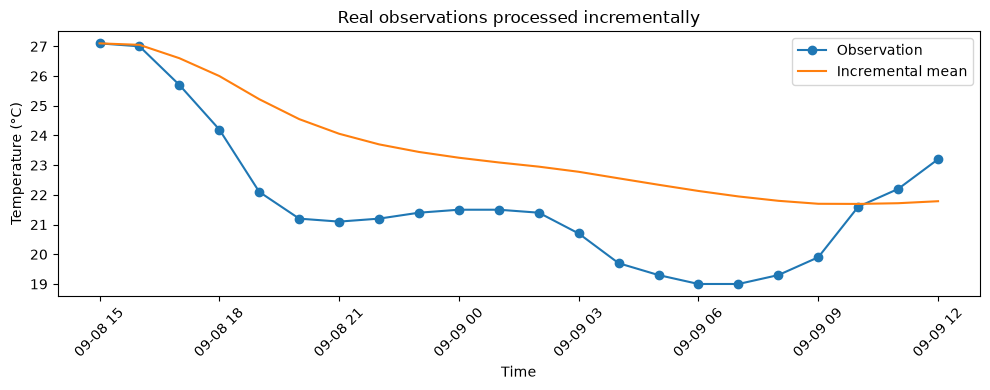

In [19]:
if not temperature_stream.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(
        temperature_stream["timestamp"],
        temperature_stream["temperatura"],
        marker="o",
        label="Observation"
    )
    plt.plot(
        temperature_stream["timestamp"],
        temperature_stream["running_mean"],
        label="Incremental mean"
    )
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.title("Real observations processed incrementally")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 6. 🌍 Open-Meteo — An Easy API for Experiments

Open-Meteo is useful when you want a simple weather API with query parameters.

This example requests hourly weather variables for Lisbon.

Unlike the IPMA station feed, weather APIs may combine observations, forecasts, models, or reanalysis products depending on the endpoint and time range.

That distinction matters in a scientific report:

> **Always describe what the data actually represents.**

In [20]:
OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"

open_meteo_params = {
    "latitude": 38.7223,
    "longitude": -9.1393,
    "hourly": (
        "temperature_2m,"
        "relative_humidity_2m,"
        "precipitation,"
        "wind_speed_10m"
    ),
    "past_days": 2,
    "forecast_days": 1,
    "timezone": "Europe/Lisbon",
}

try:
    open_meteo_json, response = fetch_json(
        OPEN_METEO_URL,
        params=open_meteo_params
    )
    print("HTTP status:", response.status_code)
    print("Request URL:", response.url)
    OPEN_METEO_AVAILABLE = True
except requests.RequestException as exc:
    print("Could not reach Open-Meteo.")
    print("Reason:", exc)
    OPEN_METEO_AVAILABLE = False
    open_meteo_json = {}

HTTP status: 200
Request URL: https://api.open-meteo.com/v1/forecast?latitude=38.7223&longitude=-9.1393&hourly=temperature_2m%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m&past_days=2&forecast_days=1&timezone=Europe%2FLisbon


In [21]:
if OPEN_METEO_AVAILABLE:
    print("Top-level keys:")
    print(open_meteo_json.keys())

    print("\nHourly keys:")
    print(open_meteo_json.get("hourly", {}).keys())

Top-level keys:
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

Hourly keys:
dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m'])


In [22]:
if OPEN_METEO_AVAILABLE and "hourly" in open_meteo_json:
    open_meteo_df = pd.DataFrame(open_meteo_json["hourly"])
    open_meteo_df["time"] = pd.to_datetime(open_meteo_df["time"])

    display(open_meteo_df.head())
else:
    open_meteo_df = pd.DataFrame()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2026-09-07 00:00:00,22.1,65,0.0,9.4
1,2026-09-07 01:00:00,21.5,70,0.0,9.4
2,2026-09-07 02:00:00,21.1,72,0.0,8.3
3,2026-09-07 03:00:00,20.9,71,0.0,6.8
4,2026-09-07 04:00:00,20.6,72,0.0,7.0


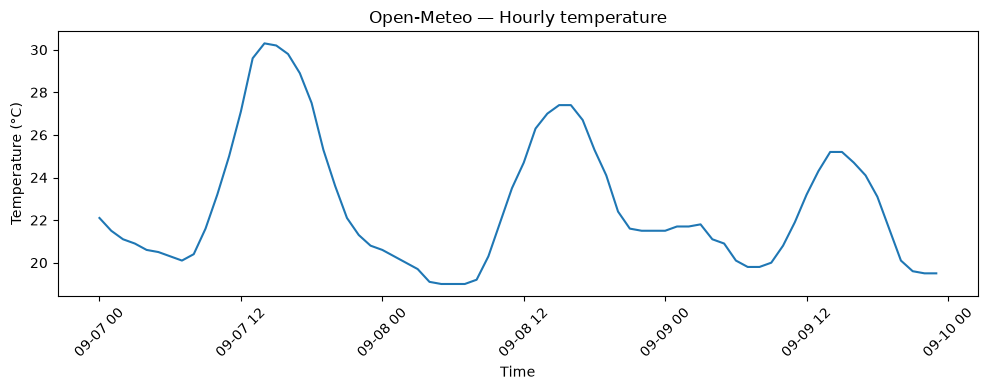

In [23]:
if (
    not open_meteo_df.empty
    and "temperature_2m" in open_meteo_df.columns
):
    plt.figure(figsize=(10, 4))
    plt.plot(
        open_meteo_df["time"],
        open_meteo_df["temperature_2m"]
    )
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.title("Open-Meteo — Hourly temperature")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### ✍️ TRY IT YOURSELF

Change the coordinates.

Examples:

| City | Latitude | Longitude |
|---|---:|---:|
| Lisbon | 38.7223 | -9.1393 |
| Porto | 41.1579 | -8.6291 |
| Faro | 37.0194 | -7.9304 |
| Funchal | 32.6669 | -16.9241 |

Then compare the resulting streams.

# 7. 🇵🇹 REN Data Hub — Portuguese Energy Data

The REN Data Hub provides JSON endpoints for electricity and gas.

Examples of available categories include:

- electricity consumption and supply;
- electricity production breakdown;
- electricity market prices;
- gas consumption;
- gas balances.

Official documentation:

```text
https://datahub.ren.pt/en/api-instructions
```

An example electricity endpoint documented by REN is:

```text
https://servicebus.ren.pt/datahubapi/electricity/ElectricityConsumptionSupplyDaily
```

Parameters include:

- `culture`
- `date`

Energy data is especially interesting for Data Stream Mining because:

- demand changes over time;
- renewable production changes over time;
- seasonality exists;
- holidays matter;
- weather matters;
- operating regimes may change.

In [24]:
REN_ELECTRICITY_URL = (
    "https://servicebus.ren.pt/datahubapi/"
    "electricity/ElectricityConsumptionSupplyDaily"
)

# Yesterday is usually safer than requesting a day that is still incomplete.
REN_DATE = (date.today() - timedelta(days=1)).isoformat()

ren_params = {
    "culture": "en-US",
    "date": REN_DATE
}

print("Date requested:", REN_DATE)

Date requested: 2026-09-08


In [25]:
try:
    ren_json, response = fetch_json(
        REN_ELECTRICITY_URL,
        params=ren_params
    )
    print("HTTP status:", response.status_code)
    print("Request URL:", response.url)
    REN_AVAILABLE = True
except requests.RequestException as exc:
    print("Could not reach the REN endpoint.")
    print("Reason:", exc)
    REN_AVAILABLE = False
    ren_json = {}

HTTP status: 200
Request URL: https://servicebus.ren.pt/datahubapi/electricity/ElectricityConsumptionSupplyDaily?culture=en-US&date=2026-09-08


## 7.1 Learning to inspect an unfamiliar API

Different providers use different JSON structures.

Instead of assuming that every endpoint looks the same, we inspect it first.

This is a real data-engineering skill.

In [26]:
if REN_AVAILABLE:
    inspect_json(ren_json, name="REN response")

REN response: list
Length: 27
First item type: dict
First item: {'daily_Accumulation': 17, 'type': 'CONSUMPTION_FOR_STORAGE'}


In [27]:
def find_record_lists(obj, path="root"):
    """Find nested lists whose elements are dictionaries.

    Useful for exploring unfamiliar JSON APIs.
    """
    found = []

    if isinstance(obj, dict):
        for key, value in obj.items():
            found.extend(
                find_record_lists(value, f"{path}.{key}")
            )

    elif isinstance(obj, list):
        if obj and all(isinstance(item, dict) for item in obj):
            found.append((path, obj))

        for i, value in enumerate(obj[:10]):
            found.extend(
                find_record_lists(value, f"{path}[{i}]")
            )

    return found

In [28]:
if REN_AVAILABLE:
    candidate_lists = find_record_lists(ren_json)

    print("Candidate record collections:")
    for path, records in candidate_lists[:20]:
        sample_keys = list(records[0].keys())[:10] if records else []
        print(
            f"- {path}: {len(records)} records "
            f"| sample keys={sample_keys}"
        )
else:
    candidate_lists = []

Candidate record collections:
- root: 27 records | sample keys=['daily_Accumulation', 'type']


### Generic normalization

If the JSON contains a clear list of records, `pd.json_normalize()` is often the fastest first step.

Because public APIs may evolve, the cell below intentionally discovers a candidate record collection rather than hard-coding one schema.

In [29]:
if candidate_lists:
    # Choose the largest discovered list of dictionary records.
    candidate_lists_sorted = sorted(
        candidate_lists,
        key=lambda item: len(item[1]),
        reverse=True
    )

    selected_path, selected_records = candidate_lists_sorted[0]

    print("Using candidate path:", selected_path)
    ren_df = pd.json_normalize(selected_records)

    display(ren_df.head())
    print("Columns:", ren_df.columns.tolist())
else:
    ren_df = pd.DataFrame()
    print(
        "No record list was automatically discovered. "
        "Inspect ren_json manually before defining a transformation."
    )

Using candidate path: root


,daily_Accumulation,type
0,17,CONSUMPTION_FOR_STORAGE
1,4,BIOMASS_OTHERS
2,17,CONSUMPTION_OF_PUMPS
3,0,BATERIES_INJECTION
4,0,BATERIES_CONSUMPTION


Columns: ['daily_Accumulation', 'type']


> **Important methodological lesson**

Do not build a report around assumptions such as:

> "The third element of this nested list is always consumption."

Instead:

1. inspect the provider schema;
2. read field names and metadata;
3. document your interpretation;
4. validate units;
5. preserve the raw response.

In [30]:
if ren_json:
    ren_raw_path = save_json(
        ren_json,
        RAW_DIR / f"ren_electricity_{REN_DATE}.json"
    )
    print("Saved raw REN response:", ren_raw_path)

if not ren_df.empty:
    ren_processed_path = (
        PROCESSED_DIR / f"ren_electricity_{REN_DATE}.csv"
    )
    ren_df.to_csv(ren_processed_path, index=False)
    print("Saved normalized REN table:", ren_processed_path)

Saved raw REN response: data\raw\ren_electricity_2026-09-08.json
Saved normalized REN table: data\processed\ren_electricity_2026-09-08.csv


# 8. 📡 ThingSpeak — Public IoT Channels

ThingSpeak is useful for understanding sensor-oriented data.

Public channels can be read through HTTP.

General endpoint pattern:

```text
https://api.thingspeak.com/channels/<CHANNEL_ID>/feeds.json
```

Optional parameters include:

- `results`
- `days`
- `minutes`

Private channels require a read API key.

The example below uses a public channel ID that can be changed by the student.

In [31]:
THINGSPEAK_CHANNEL_ID = 9
THINGSPEAK_URL = (
    f"https://api.thingspeak.com/channels/"
    f"{THINGSPEAK_CHANNEL_ID}/feeds.json"
)

thingspeak_params = {
    "results": 30
}

try:
    thingspeak_json, response = fetch_json(
        THINGSPEAK_URL,
        params=thingspeak_params
    )
    print("HTTP status:", response.status_code)
    print("Request URL:", response.url)
    THINGSPEAK_AVAILABLE = True
except requests.RequestException as exc:
    print("Could not reach the ThingSpeak public channel.")
    print("Reason:", exc)
    THINGSPEAK_AVAILABLE = False
    thingspeak_json = {}

HTTP status: 200
Request URL: https://api.thingspeak.com/channels/9/feeds.json?results=30


In [32]:
if THINGSPEAK_AVAILABLE:
    print("Channel metadata:")
    print(thingspeak_json.get("channel", {}))

    feeds = thingspeak_json.get("feeds", [])
    print("\nNumber of feed records:", len(feeds))

    thingspeak_df = pd.DataFrame(feeds)

    if not thingspeak_df.empty:
        thingspeak_df["created_at"] = pd.to_datetime(
            thingspeak_df["created_at"],
            utc=True
        )

        # ThingSpeak fields may arrive as strings.
        for col in [
            c for c in thingspeak_df.columns
            if c.startswith("field")
        ]:
            thingspeak_df[col] = pd.to_numeric(
                thingspeak_df[col],
                errors="coerce"
            )

        display(thingspeak_df.head())
else:
    thingspeak_df = pd.DataFrame()

Channel metadata:
{'id': 9, 'name': 'my_house', 'description': 'Netduino Plus connected to sensors around the house', 'latitude': '40.44', 'longitude': '-79.9965', 'field1': 'Light', 'field2': 'Outside Temperature', 'created_at': '2010-12-14T01:20:06Z', 'updated_at': '2018-07-22T04:59:08Z', 'last_entry_id': 16807751}

Number of feed records: 30


,created_at,entry_id,field1,field2
0,2026-06-28 06:56:16+00:00,16807722,30,69
1,2026-06-28 07:08:16+00:00,16807723,0,69
2,2026-06-28 07:20:26+00:00,16807724,0,69
3,2026-06-28 07:32:54+00:00,16807725,0,69
4,2026-06-28 07:44:16+00:00,16807726,0,69


### Find other public channels

ThingSpeak also provides a public channel directory:

```text
https://api.thingspeak.com/channels/public.json
```

A useful student activity is to:

1. inspect the public catalogue;
2. choose a sensor channel;
3. identify what each field means;
4. verify whether the channel is still actively producing data;
5. document the channel ID and metadata.

In [33]:
THINGSPEAK_PUBLIC_URL = (
    "https://api.thingspeak.com/channels/public.json"
)

try:
    public_channels_json, response = fetch_json(
        THINGSPEAK_PUBLIC_URL
    )

    public_channels = public_channels_json.get("channels", [])
    public_channels_df = pd.json_normalize(public_channels)

    display(public_channels_df.head(10))
except requests.RequestException as exc:
    print("Could not load the public ThingSpeak directory.")
    print("Reason:", exc)

,id,name,description,latitude,longitude,created_at,elevation,last_entry_id,public_flag,url,ranking,github_url,tags
0,624218,af104-uwz,Ultraschall-Wasser-Zähler,50.877022,9.691234,2018-11-11T21:28:02Z,222,523032.0,True,https://dweet.io/follow/af104-uwz,100,https://github.com/griemide/WemosD1mini/tree/m...,"[{'id': 13886732, 'name': 'af104-uwz'}]"
1,3487367,Sattva Hill View,Sattva Hill View is a premium residential proj...,0.0,0.0,2026-09-09T08:00:07Z,,NaN,True,https://www.sattvahillviews.com/,100,NaN,"[{'id': 14221860, 'name': 'sattva hill view'}]"
2,3124603,EMBEDO Node,"EMBEDO Node | Ambient light, weather and node'...",54.424526,18.478837,2025-10-20T11:27:00Z,150 m,497.0,True,https://www.linkedin.com/in/jr-embedo/,100,NaN,"[{'id': 13999662, 'name': 'embedo'}, {'id': 24..."
3,3486717,Sattva Vasuvi,Sattva Vasuvi is an upcoming luxury residentia...,0.0,0.0,2026-09-09T04:29:49Z,,NaN,True,https://www.sattvasvasuvi.com/,100,NaN,"[{'id': 14221812, 'name': 'sattva vasuvi'}]"
4,838448,DTT,DTT stream bitrate analysis,52.13,-0.29,2019-08-01T15:37:38Z,,13456103.0,True,https://www.terrestrialtv.uk,85,NaN,"[{'id': 25804, 'name': 'dvb-t'}, {'id': 608458..."
5,357142,Air quality with SDS011,Location: Germany (BW); \r\nMeasurement of air...,48.8628,9.3149,2017-11-01T15:11:30Z,300m MSL,381850.0,True,https://thingspeak.com/channels/357142,85,NaN,"[{'id': 674, 'name': 'air quality'}, {'id': 94..."
6,3486319,Wagner Schrubbe,Tecnologia das Coisas,0.0,0.0,2026-09-08T19:21:37Z,,5.0,True,NaN,85,NaN,"[{'id': 14221796, 'name': 'wagner schrubbe'}]"
7,1785844,Wind Power Smart Monitor,This channel is used to monitor the wind speed...,0.0,0.0,2022-06-30T17:51:49Z,,1712570.0,True,https://jessielimzhimin.wixsite.com/wind-power...,85,https://github.com/jessielimzhimin/WindPowerMo...,"[{'id': 13189343, 'name': 'wind power'}, {'id'..."
8,2057381,Wind and Solar Power Monitor,Channel is used to monitor wind and solar powe...,0.0,0.0,2023-03-08T15:54:58Z,,540531.0,True,https://dinakoushek2001.wixsite.com/wind-power...,85,https://github.com/kokyou/Iot-Project-,"[{'id': 13189343, 'name': 'wind power'}, {'id'..."
9,2862014,Power Grid Smart Monitor,This channel is used to monitor the grid frequ...,3.077683,101.7320455,2025-03-03T12:17:39Z,382.3,55328.0,True,https://eddytang2881.wixsite.com/ucsi-block-e-...,85,https://github.com/normalojy/Power-Grid-Smart-...,"[{'id': 1035, 'name': 'monitoring'}, {'id': 17..."


# 9. 🔐 API Keys and Secrets

Some APIs require authentication.

Never put a private key directly into a notebook that will be:

- uploaded to Moodle;
- sent by email;
- committed to GitHub;
- shared with classmates.

### ❌ Avoid

```python
API_KEY = "my-secret-key"
```

### ✅ Prefer environment variables

```python
import os
API_KEY = os.getenv("API_KEY")
```

Then pass the key only when making the request.

If an API key is exposed publicly, assume it may need to be revoked.

In [34]:
# Example — does not require a real key to run
example_api_key = os.getenv("EXAMPLE_API_KEY")

if example_api_key is None:
    print("No EXAMPLE_API_KEY environment variable is configured.")
else:
    print("An API key is available without printing its value.")

No EXAMPLE_API_KEY environment variable is configured.


# 10. Polling — Turning a REST API into a Continuous Collector

A REST endpoint is not automatically a push stream.

One common strategy is **polling**:

```text
request
  ↓
new data?
  ↓
save/process
  ↓
wait
  ↓
request again
```

### Important

Do not poll faster than necessary.

Respect:

- provider documentation,
- source update frequency,
- API terms of service,
- rate limits,
- server resources.

For example, if a source updates hourly, requesting it every second provides no benefit.

In [35]:
def poll_json_endpoint(
    url,
    params=None,
    interval_seconds=60,
    max_polls=3
):
    """Educational polling example.

    Keep max_polls small in class.
    Always choose an interval appropriate for the data provider.
    """
    collected = []

    for poll_number in range(1, max_polls + 1):
        print(f"Poll {poll_number}/{max_polls}")

        data, response = fetch_json(
            url,
            params=params
        )

        collected.append({
            "retrieved_at_utc": pd.Timestamp.now(tz="UTC"),
            "data": data
        })

        if poll_number < max_polls:
            time.sleep(interval_seconds)

    return collected


# Example usage — intentionally NOT executed:
#
# snapshots = poll_json_endpoint(
#     IPMA_OBSERVATIONS_URL,
#     interval_seconds=3600,
#     max_polls=2
# )

## Polling is not always the best solution

For a true event-driven system, we may prefer:

- MQTT,
- WebSockets,
- Kafka,
- another messaging/event technology.

But REST polling is easy to understand and is often sufficient for a first data-acquisition pipeline.

# 11. Live Mode vs Replay Mode

For coursework, it is useful to separate two modes.

## LIVE MODE

```text
API
 ↓
new observation
 ↓
process
 ↓
wait
 ↓
API
```

Good for:

- demonstrations,
- collection,
- dashboards,
- understanding data arrival.

---

## REPLAY MODE

```text
saved observations
 ↓
sort by timestamp
 ↓
yield one observation
 ↓
model / metric
```

Good for:

- reproducibility,
- comparing algorithms,
- repeating experiments,
- assignment evaluation.

### Recommended assignment workflow

**Collect once, replay many times.**

In [36]:
def csv_replay_stream(
    csv_path,
    timestamp_col,
    feature_cols,
    target_col=None
):
    df = pd.read_csv(csv_path)
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    yield from dataframe_replay_stream(
        df=df,
        timestamp_col=timestamp_col,
        feature_cols=feature_cols,
        target_col=target_col
    )

# 12. Data Provenance — What Must Be Documented?

A strong practical report should make it possible to understand exactly where the data came from.

At minimum, document:

1. **Provider**
2. **API / endpoint**
3. **Retrieval date**
4. **Time period represented**
5. **Timezone**
6. **Sampling / update frequency**
7. **Variables**
8. **Units**
9. **Missing-value representation**
10. **Transformations applied**
11. **Raw snapshot filename**
12. **Processed dataset filename**

This is not bureaucracy.

It is part of **reproducible Data Science**.

In [37]:
data_provenance = {
    "provider": "IPMA",
    "endpoint": IPMA_OBSERVATIONS_URL,
    "retrieved_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    "time_period": "Recent observations returned by the API",
    "timezone": "Check provider timestamps/metadata",
    "variables_used": [
        "temperatura",
        "humidade",
        "pressao",
        "precAcumulada",
        "intensidadeVento"
    ],
    "raw_file": "data/raw/ipma_observations_snapshot.json",
    "processed_file": (
        "data/processed/ipma_observations_processed.csv"
    ),
    "notes": (
        "Sentinel/missing values must be checked and documented."
    )
}

print(json.dumps(
    data_provenance,
    indent=2,
    ensure_ascii=False
))

{
  "provider": "IPMA",
  "endpoint": "https://api.ipma.pt/open-data/observation/meteorology/stations/observations.json",
  "retrieved_at_utc": "2026-09-09T15:04:19.142022+00:00",
  "time_period": "Recent observations returned by the API",
  "timezone": "Check provider timestamps/metadata",
  "variables_used": [
    "temperatura",
    "humidade",
    "pressao",
    "precAcumulada",
    "intensidadeVento"
  ],
  "raw_file": "data/raw/ipma_observations_snapshot.json",
  "processed_file": "data/processed/ipma_observations_processed.csv",
  "notes": "Sentinel/missing values must be checked and documented."
}


In [38]:
provenance_path = (
    RAW_DIR / "ipma_data_provenance.json"
)

save_json(data_provenance, provenance_path)

print("Saved:", provenance_path)

Saved: data\raw\ipma_data_provenance.json


# 13. Real Data Is Messy

When using real APIs, always investigate data quality.

Typical issues include:

- missing observations;
- duplicate timestamps;
- irregular sampling intervals;
- sentinel values;
- unit changes;
- sensor downtime;
- extreme but valid events;
- invalid measurements;
- timezone confusion;
- schema changes.

These are not merely preprocessing inconveniences.

In Data Stream Mining they can affect:

- model updates;
- anomaly detectors;
- drift detectors;
- performance metrics.

In [39]:
def basic_stream_quality_report(
    df,
    timestamp_col,
    numeric_cols=None
):
    report = {}

    if df.empty:
        return {"rows": 0}

    report["rows"] = len(df)
    report["duplicate_rows"] = int(df.duplicated().sum())

    if timestamp_col in df.columns:
        timestamps = pd.to_datetime(
            df[timestamp_col],
            errors="coerce"
        )
        report["missing_timestamps"] = int(
            timestamps.isna().sum()
        )
        report["duplicate_timestamps"] = int(
            timestamps.duplicated().sum()
        )

    if numeric_cols:
        report["missing_by_variable"] = {
            col: int(df[col].isna().sum())
            for col in numeric_cols
            if col in df.columns
        }

    return report

In [40]:
if not selected_ipma.empty:
    quality_report = basic_stream_quality_report(
        selected_ipma,
        timestamp_col="timestamp",
        numeric_cols=[
            "temperatura",
            "humidade",
            "pressao",
            "precAcumulada",
            "intensidadeVento"
        ]
    )

    print(json.dumps(
        quality_report,
        indent=2,
        ensure_ascii=False
    ))

{
  "rows": 22,
  "duplicate_rows": 0,
  "missing_timestamps": 0,
  "duplicate_timestamps": 0,
  "missing_by_variable": {
    "temperatura": 0,
    "humidade": 0,
    "pressao": 0,
    "precAcumulada": 0,
    "intensidadeVento": 0
  }
}


# 14. Approved / Suggested Real-World Data Sources

The following types of sources are especially useful for course projects.

| Source | Domain | Typical data | Difficulty |
|---|---|---|---|
| **IPMA** | Weather | temperature, humidity, pressure, precipitation, wind | ⭐ |
| **REN Data Hub** | Energy | consumption, supply, generation, market data | ⭐⭐ |
| **Open-Meteo** | Weather | hourly weather variables | ⭐ |
| **ThingSpeak** | IoT | public sensor channels | ⭐⭐ |
| **OpenAQ** | Air quality | pollutant measurements | ⭐⭐ |
| **USGS Water Data** | Hydrology | streamflow, water level, sensor measurements | ⭐⭐ |
| **Elexon** | Energy | UK electricity system data | ⭐⭐⭐ |

The exact list may be updated during the semester.

### Choosing a source

Do not choose a source only because the API is easy.

Ask:

- Is there enough temporal data?
- Is the sampling frequency meaningful?
- Are the variables interpretable?
- Can I formulate a Data Stream Mining question?
- Can I reproduce the dataset later?

In [41]:
SOURCE_CATALOG = {
    "IPMA": {
        "domain": "Weather / monitoring",
        "authentication": "No key for the endpoints used here",
        "url": (
            "https://api.ipma.pt/open-data/observation/"
            "meteorology/stations/"
        ),
    },
    "REN Data Hub": {
        "domain": "Electricity and gas",
        "authentication": "See provider documentation",
        "url": "https://datahub.ren.pt/en/api-instructions",
    },
    "Open-Meteo": {
        "domain": "Weather",
        "authentication": "Open endpoint for standard use",
        "url": "https://open-meteo.com/",
    },
    "ThingSpeak": {
        "domain": "IoT sensors",
        "authentication": (
            "Public channels readable without a private read key"
        ),
        "url": "https://thingspeak.com/",
    },
}

pd.DataFrame(SOURCE_CATALOG).T

,domain,authentication,url
IPMA,Weather / monitoring,No key for the endpoints used here,https://api.ipma.pt/open-data/observation/mete...
REN Data Hub,Electricity and gas,See provider documentation,https://datahub.ren.pt/en/api-instructions
Open-Meteo,Weather,Open endpoint for standard use,https://open-meteo.com/
ThingSpeak,IoT sensors,Public channels readable without a private rea...,https://thingspeak.com/


# 15. Bridge to the Practical Assignments

One way to create variety across practical reports is:

> **Different data sources — common methodological requirements.**

For example:

### Student A — Portuguese electricity

Data source: REN  
Possible question: energy demand / generation behavior.

### Student B — Portuguese weather

Data source: IPMA  
Possible question: precipitation, temperature, or weather-state prediction.

### Student C — IoT

Data source: ThingSpeak  
Possible question: sensor anomaly or state prediction.

### Student D — Environmental monitoring

Data source: air-quality or water-monitoring API.

The **domain changes**, but the scientific structure of the report can remain comparable.

## Suggested common report structure

A practical report based on API data could contain:

### 1. Data Source
Who provides the data?

### 2. Data Acquisition
Which API and parameters were used?

### 3. Stream Definition
What is one observation?

### 4. Temporal Structure
What is the sampling/update frequency?

### 5. Data Quality & Preprocessing
How were missing/invalid values handled?

### 6. Task Definition
What should the algorithm predict, detect, or model?

### 7. Stream Mining Method
Which incremental method is used?

### 8. Online Evaluation
How is performance measured over time?

### 9. Computational Considerations
Memory, processing time, model complexity.

### 10. Critical Discussion
What worked? What failed? What are the limitations?

> **The dataset may differ between students.  
> The scientific reasoning should not.**

# 16. ✍️ Optional Mini-Activity — Choose a Real Source

No submission is required.

Choose **one** source from this notebook.

Then answer:

1. What entity produces the observations?
2. What is one observation?
3. What is the timestamp?
4. What variables exist?
5. What units are used?
6. Are there missing values?
7. How frequently does new data appear?
8. What could be a target variable?
9. What could constitute an anomaly?
10. What might cause concept drift?

This activity is intentionally open-ended.

The goal is to start seeing APIs not merely as data-download tools, but as **potential stream sources**.

# 17. Self-Check

Before using an API in an assignment, you should be able to explain:

- What is an HTTP `GET` request?
- What is JSON?
- How do you inspect nested JSON?
- Why should raw data be saved?
- Why are timestamps essential?
- What is polling?
- What is the difference between live collection and replay?
- Why should API keys not be hard-coded?
- What information belongs in data provenance?
- Why can two students use different sources while still being evaluated with the same methodological rubric?

# ✅ End — From APIs to Data Streams

The central pipeline of this notebook is:

**SOURCE → API → JSON → RAW SNAPSHOT → DATAFRAME → TIMESTAMP ORDER → REPLAY STREAM**

Later, we will extend the pipeline:

**STREAM → PREPROCESS → PREDICT → EVALUATE → LEARN → DETECT → ADAPT**

That is where data acquisition becomes **Data Stream Mining**.